In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('week1/insurance_claims.csv')
df.shape

(1000, 40)

In [22]:
#Drop the _c39 column
df = df.drop(columns=['_c39'])

In [7]:
df.shape

(1000, 39)

In [23]:
#Replace ? with Unknown in collision_type
df['collision_type'] = df['collision_type'].replace('?', 'unknown')
print(df['collision_type'].value_counts())

collision_type
Rear Collision     292
Side Collision     276
Front Collision    254
unknown            178
Name: count, dtype: int64


In [24]:
#Fill nulls in authorities_contacted with Unknown
df['authorities_contacted'] = df['authorities_contacted'].fillna('unknown')
print(df['authorities_contacted'].value_counts())

authorities_contacted
Police       292
Fire         223
Other        198
Ambulance    196
unknown       91
Name: count, dtype: int64


In [25]:
#Filter for only rows where fraud_reported == 'Y'

frt = df[df['fraud_reported'] == 'Y'].copy()

print(f"Fraud_reported: {len(frt)}")


Fraud_reported: 247


In [26]:
#From that filtered dataset, show the value_counts() of incident_type
print(frt['incident_type'].value_counts())

incident_type
Single Vehicle Collision    117
Multi-vehicle Collision     114
Vehicle Theft                 8
Parked Car                    8
Name: count, dtype: int64


In [27]:
#What percentage of fraudulent claims are Single Vehicle Collisions?
svc=frt['incident_type'].value_counts(normalize=True). round(3) *100
print(svc)

incident_type
Single Vehicle Collision    47.4
Multi-vehicle Collision     46.2
Vehicle Theft                3.2
Parked Car                   3.2
Name: proportion, dtype: float64


In [28]:
#Fraud rate by incident type using groupby and value_counts(normalize=True)
#Unstack it

fraud_rate = df.groupby('incident_type')['fraud_reported'].value_counts(normalize=True).round(3) *100
fraud_rate = fraud_rate.unstack() 
print(fraud_rate)

fraud_reported               N     Y
incident_type                       
Multi-vehicle Collision   72.8  27.2
Parked Car                90.5   9.5
Single Vehicle Collision  71.0  29.0
Vehicle Theft             91.5   8.5


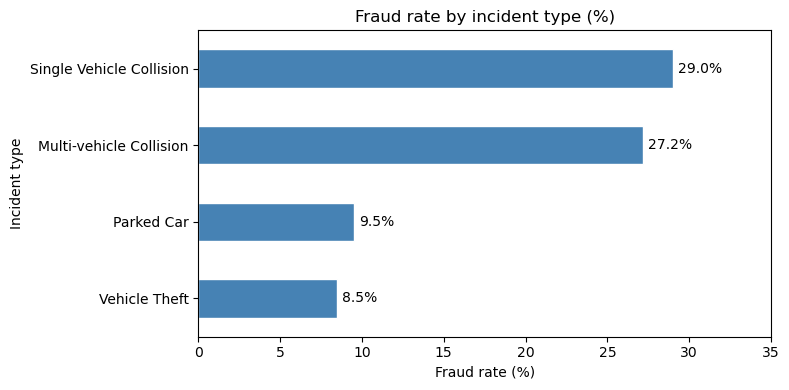

In [34]:
#Plot the Y column as a horizontal bar chart with labels
ax = fraud_rate['Y'].sort_values().plot(
    kind ='barh',
    figsize=(8,4),
    color='steelblue',
    edgecolor ='white'
)

plt.title('Fraud rate by incident type (%)')
plt.xlabel('Fraud rate (%)')
plt.ylabel('Incident type')

for i, v in enumerate(fraud_rate['Y'].sort_values()):
    ax.text(round(v, 1) + 0.3, i, f'{round(v, 1)}%', va='center', fontsize=10)

plt.xlim(0, 35)
plt.tight_layout()
plt.show()

 